# Step 2C — log1p(temporal) Across All 5 Classifiers

**Goal.** Step 2B showed that `log1p` transformation of the 3 temporal features rescues SVM (F1 0.14 → 0.76 on Exp 3), beating even full coordination-family removal. This notebook tests the same transformation across all five classifiers to determine whether the scale fix is SVM-specific or universal.

**Hypothesis.**
- **SVM**: large gain (already confirmed in 2B)
- **DT, RF**: tree-based methods are scale-invariant in principle, so log should not help — if they recover under `full_logtmp`, the mechanism is something other than scale-invariance (e.g., tree splits don't see the order-of-magnitude difference, but small-data noise in extreme tail values still creates bad splits)
- **NB**: uses min-max scaling internally; log transform changes the relative density but values still get rescaled to [0, 1]. Modest effect expected.
- **DNN**: uses StandardScaler internally; gradient-based optimization is sensitive to outliers, so log might help noticeably.

**Decision branch:**
- *Universal rescue (all 5 improve)* → unified story: "heavy-tailed temporal features destabilize multiple classifier families; log1p is the universal fix"
- *SVM-only rescue* → two-part story: SVM fails due to scale, tree methods fail for a different reason (correlated-feature redundancy)

**Configurations tested (per experiment):**
- `full` — Week 1 baseline
- `drop_temp` — remove the 3 temporal features
- `full_logtmp` — full set with log1p(temporal) instead of raw temporal
- `drop_coord_all` — Week 1 drop_coordination reference

4 configs × 5 classifiers × 3 experiments = **60 runs.**

**Outputs:**
- `step2c_full_classifier_results.csv` — long-form
- `step2c_log_rescue_summary.csv` — per-classifier rescue fraction
- `step2c_heatmap.png` — F1 heatmap

## Cell 1 — Imports and feature definitions

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.naive_bayes    import MultinomialNB
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import LinearSVC
from sklearn.tree           import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

TEMPORAL = ['delta_mean_s', 'delta_std_s', 'delta_min_s']

CONTENT_DIMS    = ['political', 'attack', 'emotional', 'low_effort', 'authenticity']
STRUCTURAL_DIMS = ['emoji', 'length', 'repetition', 'punctuation', 'caps']
COORD_DIMS      = ['coordination', 'algorithmic']
AGGS = ['mean', 'max', 'std', 'sum']
expand = lambda dims: [f'{d}_{a}' for d in dims for a in AGGS]

L_CONTENT    = expand(CONTENT_DIMS)
L_STRUCTURAL = expand(STRUCTURAL_DIMS)
L_COORD_NON_TEMPORAL = (expand(COORD_DIMS)
                       + ['overall_max', 'overall_mean', 'n_high_score', 'n_med_score']
                       + ['n_comments', 'n_threads', 'likes_total', 'likes_per_comment',
                          'threads_per_comment', 'likes_mean', 'replies_mean'])

cols_full     = L_CONTENT + L_STRUCTURAL + L_COORD_NON_TEMPORAL + TEMPORAL
cols_droptemp = L_CONTENT + L_STRUCTURAL + L_COORD_NON_TEMPORAL
cols_dropall  = L_CONTENT + L_STRUCTURAL

print(f'full = {len(cols_full)} features')
print(f'drop_temp = {len(cols_droptemp)} features')
print(f'drop_coord_all = {len(cols_dropall)} features')


2026-05-25 23:57:21.474793: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-25 23:57:21.474821: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-25 23:57:21.474838: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-25 23:57:21.479736: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-25 23:57:22.700032: W tensorflow/compiler/

full = 62 features
drop_temp = 59 features
drop_coord_all = 40 features


## Cell 2 — Classifier suite

In [2]:
def metrics(y_true, y_pred):
    return {'recall':    recall_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'f1':        f1_score(y_true, y_pred, zero_division=0)}

def fit_predict_all(Xtr, ytr, Xte):
    out = {}

    mm = MinMaxScaler().fit(Xtr)
    nb = MultinomialNB(alpha=1.0).fit(mm.transform(Xtr), ytr)
    out['NB'] = nb.predict(mm.transform(Xte))

    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
    out['RF'] = rf.predict(Xte)

    svm = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000).fit(Xtr, ytr)
    out['SVM'] = svm.predict(Xte)

    ss = StandardScaler().fit(Xtr)
    Xtr_ss, Xte_ss = ss.transform(Xtr), ss.transform(Xte)
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    dnn = Sequential([
        Input(shape=(Xtr_ss.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid'),
    ])
    dnn.compile(optimizer=SGD(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    dnn.fit(Xtr_ss, ytr, epochs=200, batch_size=16, verbose=0)
    out['DNN'] = (dnn.predict(Xte_ss, verbose=0).ravel() >= 0.5).astype(int)

    n_splits = min(5, max(2, int(ytr.sum())))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    dt_gs = GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]},
        scoring='f1', cv=skf, n_jobs=-1,
    ).fit(Xtr, ytr)
    out['DT'] = dt_gs.predict(Xte)
    return out

def get_matrices(tr, te, config):
    """Return Xtr, Xte for a given config."""
    if config == 'full':
        return tr[cols_full].values, te[cols_full].values
    elif config == 'drop_temp':
        return tr[cols_droptemp].values, te[cols_droptemp].values
    elif config == 'drop_coord_all':
        return tr[cols_dropall].values, te[cols_dropall].values
    elif config == 'full_logtmp':
        tr_c = tr.copy(); te_c = te.copy()
        for c in TEMPORAL:
            tr_c[c] = np.log1p(tr[c].clip(lower=0))
            te_c[c] = np.log1p(te[c].clip(lower=0))
        return tr_c[cols_full].values, te_c[cols_full].values
    else:
        raise ValueError(config)


## Cell 3 — Run the grid (60 runs)

In [3]:
CONFIGS = ['full', 'drop_temp', 'full_logtmp', 'drop_coord_all']

rows = []
t0 = time.time()
total = 3 * len(CONFIGS)
done = 0
for exp_id in (1, 2, 3):
    tr = pd.read_csv(f'../phase2_train_exp{exp_id}.csv')
    te = pd.read_csv(f'../phase2_test_exp{exp_id}.csv')
    ytr, yte = tr['label'].values, te['label'].values

    for cfg in CONFIGS:
        Xtr, Xte = get_matrices(tr, te, cfg)
        preds = fit_predict_all(Xtr, ytr, Xte)
        for clf, ypred in preds.items():
            m = metrics(yte, ypred)
            rows.append({'experiment': exp_id, 'config': cfg,
                         'n_features': Xtr.shape[1], 'classifier': clf, **m})
        done += 1
        elapsed = time.time() - t0
        eta = (elapsed / done) * (total - done) if done else 0
        print(f'[{done:2d}/{total}]  exp{exp_id}  {cfg:16s}  '
              f'elapsed={elapsed:5.1f}s  eta={eta:5.1f}s')

results = pd.DataFrame(rows)
results.to_csv('step2c_full_classifier_results.csv', index=False)
print(f'\n→ {len(results)} rows → step2c_full_classifier_results.csv')


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
2026-05-25 23:57:24.418430: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-05-25 23:57:24.418466: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: idea-26
2026-05-25 23:57:24.418471: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: idea-26
2026-05-25 23:57:24.418578: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.c

[ 1/12]  exp1  full              elapsed=  2.4s  eta= 26.5s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[ 2/12]  exp1  drop_temp         elapsed=  3.8s  eta= 19.1s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


...

[10/12]  exp3  drop_temp         elapsed= 18.1s  eta=  3.6s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[11/12]  exp3  full_logtmp       elapsed= 20.3s  eta=  1.8s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[12/12]  exp3  drop_coord_all    elapsed= 22.5s  eta=  0.0s

→ 60 rows → step2c_full_classifier_results.csv


## Cell 4 — Per-classifier F1 across configs

In [4]:
CONFIG_ORDER = ['full', 'drop_temp', 'full_logtmp', 'drop_coord_all']
CLF_ORDER    = ['NB', 'RF', 'SVM', 'DNN', 'DT']

pivot = results.pivot_table(index=['classifier','experiment'],
                             columns='config', values='f1').reindex(columns=CONFIG_ORDER) \
                 .reindex([(c, e) for c in CLF_ORDER for e in (1,2,3)]).round(4)
print('F1 per (classifier, experiment) × config:')
print(pivot.to_string())


F1 per (classifier, experiment) × config:
config                   full  drop_temp  full_logtmp  drop_coord_all
classifier experiment                                                
NB         1           0.6507     0.6348       0.6404          0.2462
           2           0.6961     0.6882       0.6842          0.2424
           3           0.6972     0.6909       0.7143          0.3175
RF         1           0.2149     0.2707       0.1849          0.6348
           2           0.3125     0.2626       0.3158          0.6784
           3           0.2456     0.1154       0.2456          0.6526
SVM        1           0.2443     0.6040       0.6537          0.6527
           2           0.3429     0.6826       0.7160          0.6923
           3           0.1351     0.7071       0.7600          0.6535
DNN        1           0.5946     0.6010       0.5856          0.6124
           2           0.6883     0.6625       0.6933          0.6629
           3           0.7292     0.6598       0

## Cell 5 — Heatmap

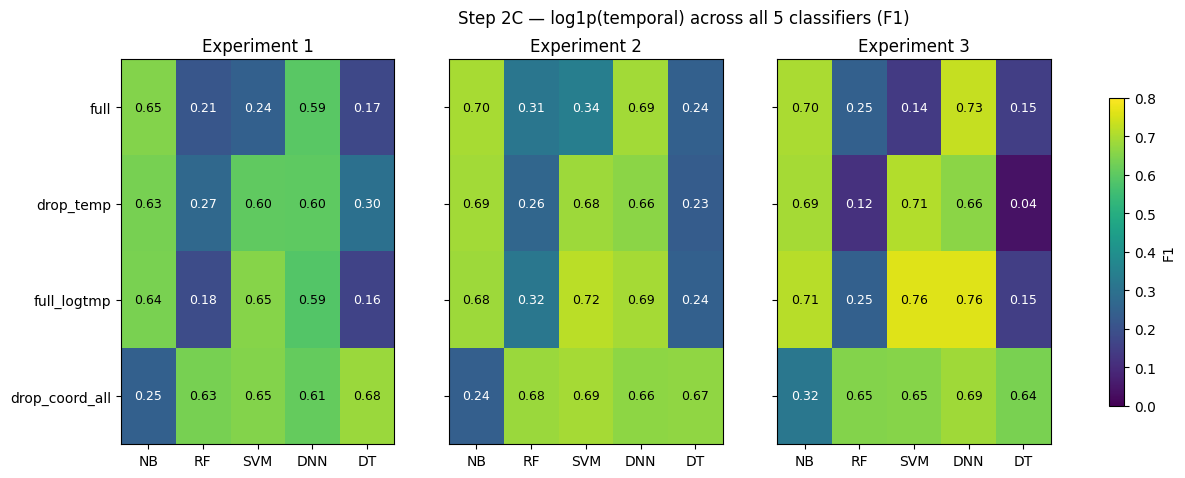

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
vmax = max(0.8, results['f1'].max() * 1.05)

for ax, exp_id in zip(axes, (1, 2, 3)):
    sub = results[results['experiment'] == exp_id]
    mat = sub.pivot(index='config', columns='classifier', values='f1') \
             .reindex(CONFIG_ORDER).reindex(columns=CLF_ORDER)

    im = ax.imshow(mat.values, cmap='viridis', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(CLF_ORDER)));   ax.set_xticklabels(CLF_ORDER)
    ax.set_yticks(range(len(CONFIG_ORDER))); ax.set_yticklabels(CONFIG_ORDER)
    ax.set_title(f'Experiment {exp_id}')

    for i in range(len(CONFIG_ORDER)):
        for j in range(len(CLF_ORDER)):
            v = mat.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < vmax * 0.55 else 'black', fontsize=9)

fig.suptitle('Step 2C — log1p(temporal) across all 5 classifiers (F1)', fontsize=12)
fig.colorbar(im, ax=axes, shrink=0.8, label='F1')
plt.savefig('step2c_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 6 — Rescue summary per classifier

In [6]:
rows = []
for clf in CLF_ORDER:
    for exp_id in (1, 2, 3):
        f1_full     = float(results[(results.classifier==clf)&(results.experiment==exp_id)&(results.config=='full')]['f1'].iloc[0])
        f1_droptmp  = float(results[(results.classifier==clf)&(results.experiment==exp_id)&(results.config=='drop_temp')]['f1'].iloc[0])
        f1_logtmp   = float(results[(results.classifier==clf)&(results.experiment==exp_id)&(results.config=='full_logtmp')]['f1'].iloc[0])
        f1_dropall  = float(results[(results.classifier==clf)&(results.experiment==exp_id)&(results.config=='drop_coord_all')]['f1'].iloc[0])

        # Rescue fraction = (logtmp - full) / (dropall - full), where positive denominator means the rescue exists
        rescue_gap = f1_dropall - f1_full
        log_gain   = f1_logtmp - f1_full
        log_recovers = (log_gain / rescue_gap) if rescue_gap > 0 else None

        rows.append({
            'classifier': clf,
            'experiment': exp_id,
            'f1_full':         round(f1_full, 4),
            'f1_drop_temp':    round(f1_droptmp, 4),
            'f1_full_logtmp':  round(f1_logtmp, 4),
            'f1_drop_coord':   round(f1_dropall, 4),
            'log_gain':        round(log_gain, 4),
            'rescue_gap':      round(rescue_gap, 4),
            'log_recovery_pct':round(log_recovers * 100, 1) if log_recovers is not None else None,
            'logtmp_is_best':  bool(f1_logtmp == max(f1_full, f1_droptmp, f1_logtmp, f1_dropall)),
        })
summary = pd.DataFrame(rows)
summary.to_csv('step2c_log_rescue_summary.csv', index=False)
print('Per-classifier log-transform effect:')
print(summary.to_string(index=False))


Per-classifier log-transform effect:
classifier  experiment  f1_full  f1_drop_temp  f1_full_logtmp  f1_drop_coord  log_gain  rescue_gap  log_recovery_pct  logtmp_is_best
        NB           1   0.6507        0.6348          0.6404         0.2462   -0.0104     -0.4046               NaN           False
        NB           2   0.6961        0.6882          0.6842         0.2424   -0.0119     -0.4537               NaN           False
        NB           3   0.6972        0.6909          0.7143         0.3175    0.0170     -0.3798               NaN            True
        RF           1   0.2149        0.2707          0.1849         0.6348   -0.0300      0.4199              -7.1           False
        RF           2   0.3125        0.2626          0.3158         0.6784    0.0033      0.3659               0.9           False
        RF           3   0.2456        0.1154          0.2456         0.6526    0.0000      0.4070               0.0           False
       SVM           1   0.2443 

## Cell 7 — Verdict

In [8]:
lines = []
lines.append('=' * 72)
lines.append('STEP 2C VERDICT — Is log1p(temporal) a universal fix?')
lines.append('=' * 72)
lines.append('')

# For each classifier, compute mean log gain across experiments
mean_log_gain = summary.groupby('classifier')['log_gain'].mean()
mean_logtmp_best = summary.groupby('classifier')['logtmp_is_best'].mean()

lines.append('Mean log_gain across 3 experiments (f1_logtmp − f1_full):')
for clf in CLF_ORDER:
    g = mean_log_gain[clf]
    best_rate = int(mean_logtmp_best[clf] * 3)
    if g > 0.05:
        tag = '✓ HELPS'
    elif g > -0.05:
        tag = '— neutral'
    else:
        tag = '✗ HURTS'
    lines.append(f'  {clf:4s}  log_gain={g:+.3f}   logtmp_is_best on {best_rate}/3 exps   {tag}')
lines.append('')

helps  = [c for c in CLF_ORDER if mean_log_gain[c] > 0.05]
hurts  = [c for c in CLF_ORDER if mean_log_gain[c] < -0.05]

lines.append('Helps:   ' + (', '.join(helps) if helps else '(none)'))
lines.append('Hurts:   ' + (', '.join(hurts) if hurts else '(none)'))
lines.append('Neutral: ' + (', '.join(c for c in CLF_ORDER if c not in helps and c not in hurts) or '(none)'))
lines.append('')

if len(helps) >= 4:
    lines.append('✅ UNIVERSAL RESCUE — log1p(temporal) helps 4+ classifiers.')
    lines.append('   Story: "Heavy-tailed temporal features destabilize multiple classifier families;')
    lines.append('    log1p preprocessing is a universal fix that preserves the temporal signal."')
elif 'SVM' in helps and len(helps) <= 2:
    lines.append('⚠ SVM-PRIMARY RESCUE — log1p helps SVM strongly but few others.')
    lines.append('   Story: "Two-part finding. SVM fails due to scale (fixed by log1p).')
    lines.append('    Tree-based methods fail for a different reason (correlated-feature redundancy),')
    lines.append('    requiring full L-coordination removal."')
elif helps:
    lines.append(f'⚠ PARTIAL — log1p helps {len(helps)} classifier(s): {helps}.')
    lines.append('   Story: mixed effect. Report per-classifier; do not generalize.')
else:
    lines.append('❌ NO EFFECT — log1p does not help any classifier consistently.')
    lines.append('   The Step 2B SVM result may be split-specific. Walk back the log-transform claim.')

txt = '\n'.join(lines)
print(txt)
with open('step2c_verdict.txt', 'w', encoding='utf-8') as f:
    f.write(txt)


STEP 2C VERDICT — Is log1p(temporal) a universal fix?

Mean log_gain across 3 experiments (f1_logtmp − f1_full):
  NB    log_gain=-0.002   logtmp_is_best on 1/3 exps   — neutral
  RF    log_gain=-0.009   logtmp_is_best on 0/3 exps   — neutral
  SVM   log_gain=+0.469   logtmp_is_best on 3/3 exps   ✓ HELPS
  DNN   log_gain=+0.009   logtmp_is_best on 2/3 exps   — neutral
  DT    log_gain=-0.004   logtmp_is_best on 0/3 exps   — neutral

Helps:   SVM
Hurts:   (none)
Neutral: NB, RF, DNN, DT

⚠ SVM-PRIMARY RESCUE — log1p helps SVM strongly but few others.
   Story: "Two-part finding. SVM fails due to scale (fixed by log1p).
    Tree-based methods fail for a different reason (correlated-feature redundancy),
    requiring full L-coordination removal."


## Done

Four outputs:
- `step2c_full_classifier_results.csv` — 60 rows
- `step2c_log_rescue_summary.csv` — per (classifier, experiment) summary
- `step2c_heatmap.png` — config × classifier heatmap
- `step2c_verdict.txt` — automated read

Runtime ~5–10 min, dominated by DT GridSearch.

After this, regardless of verdict, you have the full picture for Ch 5. **No more experiments after this one.** Commit and draft.